In [1]:
!ls /kaggle/input/datasets/trainingdatapro/pose-estimation/PoseEstimation/

collage  fiile_info.csv  PE


In [2]:
import xml.etree.ElementTree as ET

xml_path = "/kaggle/input/datasets/trainingdatapro/pose-estimation/annotations.xml"

tree = ET.parse(xml_path)
root = tree.getroot()

print("Root:", root.tag)

for child in root[:5]:
    print("\nTAG:", child.tag)
    print("ATTR:", child.attrib)

    for sub in child[:5]:
        print("   ", sub.tag, sub.attrib)

Root: annotations

TAG: version
ATTR: {}

TAG: meta
ATTR: {}
    task {}
    dumped {}

TAG: image
ATTR: {'id': '0', 'name': 'PE/0.jpg', 'width': '3580', 'height': '5370'}
    points {'label': '1', 'occluded': '0', 'source': 'manual', 'points': '1371.13,1385.42', 'z_order': '0'}
    points {'label': '2', 'occluded': '0', 'source': 'manual', 'points': '1152.69,1381.02', 'z_order': '0'}
    points {'label': '3', 'occluded': '0', 'source': 'manual', 'points': '974.97,993.31', 'z_order': '0'}
    points {'label': '4', 'occluded': '0', 'source': 'manual', 'points': '810.17,465.79', 'z_order': '0'}
    points {'label': '5', 'occluded': '0', 'source': 'manual', 'points': '1627.15,1471.94', 'z_order': '0'}

TAG: image
ATTR: {'id': '1', 'name': 'PE/1.jpg', 'width': '3217', 'height': '4825'}
    points {'label': '9', 'occluded': '0', 'source': 'manual', 'points': '922.88,3542.87', 'z_order': '0'}
    points {'label': '11', 'occluded': '0', 'source': 'manual', 'points': '1549.90,2877.07', 'z_orde

In [3]:
import pandas as pd

csv_path = "/kaggle/input/datasets/trainingdatapro/pose-estimation/PoseEstimation/fiile_info.csv"

df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)

   image_id     image_name collage_name
0         0  collage/0.jpg     PE/0.jpg
1         1  collage/1.jpg     PE/1.jpg
2        12  collage/2.jpg     PE/2.jpg
3        22  collage/3.jpg     PE/3.jpg
4        23  collage/4.jpg     PE/4.jpg
Index(['image_id', 'image_name', 'collage_name'], dtype='object')


In [4]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET

from PIL import Image

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import resnet18

import matplotlib.pyplot as plt

In [5]:
XML_FILE = "/kaggle/input/datasets/trainingdatapro/pose-estimation/annotations.xml"

tree = ET.parse(XML_FILE)
root = tree.getroot()

data = []

for image_tag in root.findall("image"):

    image_name = image_tag.attrib["name"]

    width = int(image_tag.attrib["width"])
    height = int(image_tag.attrib["height"])

    keypoints = np.zeros((18,2))

    for point in image_tag.findall("points"):

        label = int(point.attrib["label"])

        x,y = map(float, point.attrib["points"].split(","))

        if label < 18:
            keypoints[label] = [x,y]

    data.append(
        {
            "image": image_name,
            "width": width,
            "height": height,
            "keypoints": keypoints
        }
    )

print("Images:",len(data))

Images: 29


In [6]:
class PoseDataset(Dataset):

    def __init__(self,data,root_dir):

        self.data = data
        self.root_dir = root_dir

        self.transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self,idx):

        sample = self.data[idx]

        image_path = os.path.join(
            self.root_dir,
            sample["image"]
        )

        image = Image.open(image_path).convert("RGB")

        w = sample["width"]
        h = sample["height"]

        kp = sample["keypoints"].copy()

        kp[:,0] /= w
        kp[:,1] /= h

        image = self.transform(image)

        kp = torch.tensor(
            kp.flatten(),
            dtype=torch.float32
        )

        return image,kp

In [7]:
from sklearn.model_selection import train_test_split

train_data,test_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

ROOT_DIR = "/kaggle/input/datasets/trainingdatapro/pose-estimation/PoseEstimation"

train_dataset = PoseDataset(
    train_data,
    ROOT_DIR
)

test_dataset = PoseDataset(
    test_data,
    ROOT_DIR
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16
)

In [8]:
class PoseNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = resnet18(weights="DEFAULT")
        self.backbone.fc = nn.Linear(
            512,
            36
        )

    def forward(self,x):
        return self.backbone(x)

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = PoseNet().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 210MB/s]


In [10]:
from tqdm.auto import tqdm

epochs = 20

for epoch in range(epochs):

    model.train()

    running_loss = 0

    bar = tqdm(train_loader)

    for images,keypoints in bar:

        images = images.to(device)
        keypoints = keypoints.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            keypoints
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        bar.set_description(
            f"Epoch {epoch+1}"
        )

        bar.set_postfix(
            loss=running_loss/(bar.n+1)
        )

    print(
        f"Epoch {epoch+1}: "
        f"{running_loss/len(train_loader):.4f}"
    )

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1: 0.5870


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2: 0.3720


  0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 18: 0.0203


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19: 0.0171


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20: 0.0161


In [11]:
SKELETON = [

    (0,1),(1,2),(2,3),(3,4),

    (1,5),(5,6),(6,7),

    (1,8),(8,9),(9,10),

    (1,11),(11,12),(12,13),

    (0,14),(14,16),

    (0,15),(15,17)
]

Left Elbow  : 35.8°
Right Elbow : 86.7°
Left Knee   : 20.8°
Right Knee  : 37.9°


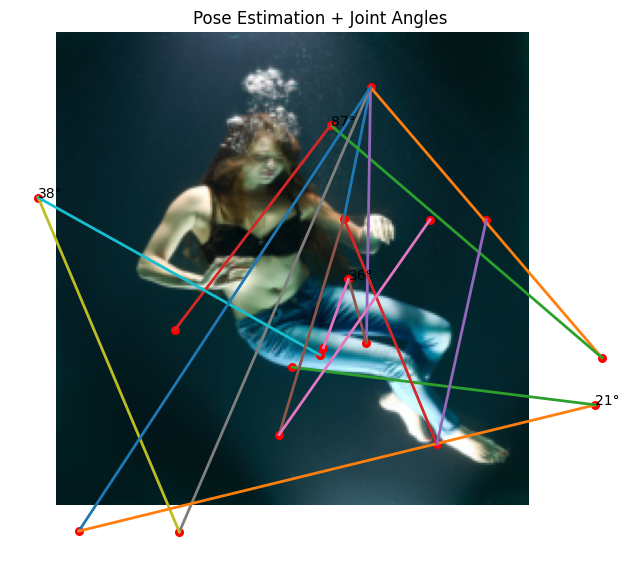

In [22]:
model.eval()

image,kp_true = test_dataset[0]

with torch.no_grad():

    pred = model(
        image.unsqueeze(0).to(device)
    )

pred = pred.cpu().numpy().reshape(18,2)

# ----------------------------
# Angle Function
# ----------------------------

def calculate_angle(a,b,c):

    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba,bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc)
    )

    cosine_angle = np.clip(
        cosine_angle,
        -1,
        1
    )

    angle = np.degrees(
        np.arccos(cosine_angle)
    )

    return angle

# ----------------------------
# Calculate Angles
# ----------------------------

left_elbow = calculate_angle(
    pred[5],
    pred[6],
    pred[7]
)

right_elbow = calculate_angle(
    pred[2],
    pred[3],
    pred[4]
)

left_knee = calculate_angle(
    pred[11],
    pred[12],
    pred[13]
)

right_knee = calculate_angle(
    pred[8],
    pred[9],
    pred[10]
)

print(f"Left Elbow  : {left_elbow:.1f}°")
print(f"Right Elbow : {right_elbow:.1f}°")
print(f"Left Knee   : {left_knee:.1f}°")
print(f"Right Knee  : {right_knee:.1f}°")

# ----------------------------
# Draw Skeleton
# ----------------------------

img = image.permute(
    1,2,0
).numpy()

h,w,_ = img.shape

pred[:,0] *= w
pred[:,1] *= h

plt.figure(figsize=(8,8))
plt.imshow(img)

# Draw joints
for x,y in pred:

    plt.scatter(
        x,
        y,
        c='red',
        s=30
    )

# Draw skeleton
for p1,p2 in SKELETON:

    x1,y1 = pred[p1]
    x2,y2 = pred[p2]

    plt.plot(
        [x1,x2],
        [y1,y2],
        linewidth=2
    )

# ----------------------------
# Display Angles
# ----------------------------

plt.text(
    pred[6][0],
    pred[6][1],
    f"{left_elbow:.0f}°",
    fontsize=10
)

plt.text(
    pred[3][0],
    pred[3][1],
    f"{right_elbow:.0f}°",
    fontsize=10
)

plt.text(
    pred[12][0],
    pred[12][1],
    f"{left_knee:.0f}°",
    fontsize=10
)

plt.text(
    pred[9][0],
    pred[9][1],
    f"{right_knee:.0f}°",
    fontsize=10
)

plt.title("Pose Estimation + Joint Angles")

plt.axis("off")
plt.show()

In [23]:
def predict_pose(image_path):

    model.eval()

    img = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    tensor = transform(img)

    with torch.no_grad():

        pred = model(
            tensor.unsqueeze(0).to(device)
        )

    pred = pred.cpu().numpy().reshape(18,2)

    # -----------------------------
    # Angle Calculation Function
    # -----------------------------

    def calculate_angle(a,b,c):

        a = np.array(a)
        b = np.array(b)
        c = np.array(c)

        ba = a - b
        bc = c - b

        cosine_angle = np.dot(ba,bc) / (
            np.linalg.norm(ba) * np.linalg.norm(bc)
        )

        cosine_angle = np.clip(
            cosine_angle,
            -1.0,
            1.0
        )

        angle = np.degrees(
            np.arccos(cosine_angle)
        )

        return angle

    # -----------------------------
    # Joint Angles
    # -----------------------------

    left_elbow = calculate_angle(
        pred[5],
        pred[6],
        pred[7]
    )

    right_elbow = calculate_angle(
        pred[2],
        pred[3],
        pred[4]
    )

    left_knee = calculate_angle(
        pred[11],
        pred[12],
        pred[13]
    )

    right_knee = calculate_angle(
        pred[8],
        pred[9],
        pred[10]
    )

    print(f"Left Elbow  : {left_elbow:.1f}°")
    print(f"Right Elbow : {right_elbow:.1f}°")
    print(f"Left Knee   : {left_knee:.1f}°")
    print(f"Right Knee  : {right_knee:.1f}°")

    # -----------------------------
    # Visualization
    # -----------------------------

    img_np = np.array(
        img.resize((224,224))
    )

    plt.figure(figsize=(10,10))
    plt.imshow(img_np)

    # Draw joints

    for x,y in pred:

        plt.scatter(
            x*224,
            y*224,
            s=50
        )

    # Draw skeleton

    for p1,p2 in SKELETON:

        plt.plot(
            [pred[p1][0]*224,
             pred[p2][0]*224],

            [pred[p1][1]*224,
             pred[p2][1]*224],

            linewidth=2
        )

    # -----------------------------
    # Display Angles
    # -----------------------------

    plt.text(
        pred[6][0]*224,
        pred[6][1]*224,
        f"{left_elbow:.0f}°",
        fontsize=12
    )

    plt.text(
        pred[3][0]*224,
        pred[3][1]*224,
        f"{right_elbow:.0f}°",
        fontsize=12
    )

    plt.text(
        pred[12][0]*224,
        pred[12][1]*224,
        f"{left_knee:.0f}°",
        fontsize=12
    )

    plt.text(
        pred[9][0]*224,
        pred[9][1]*224,
        f"{right_knee:.0f}°",
        fontsize=12
    )

    plt.title("Pose Estimation + Skeleton + Joint Angles")

    plt.axis("off")

    plt.show()

Left Elbow  : 130.1°
Right Elbow : 93.8°
Left Knee   : 110.8°
Right Knee  : 71.1°


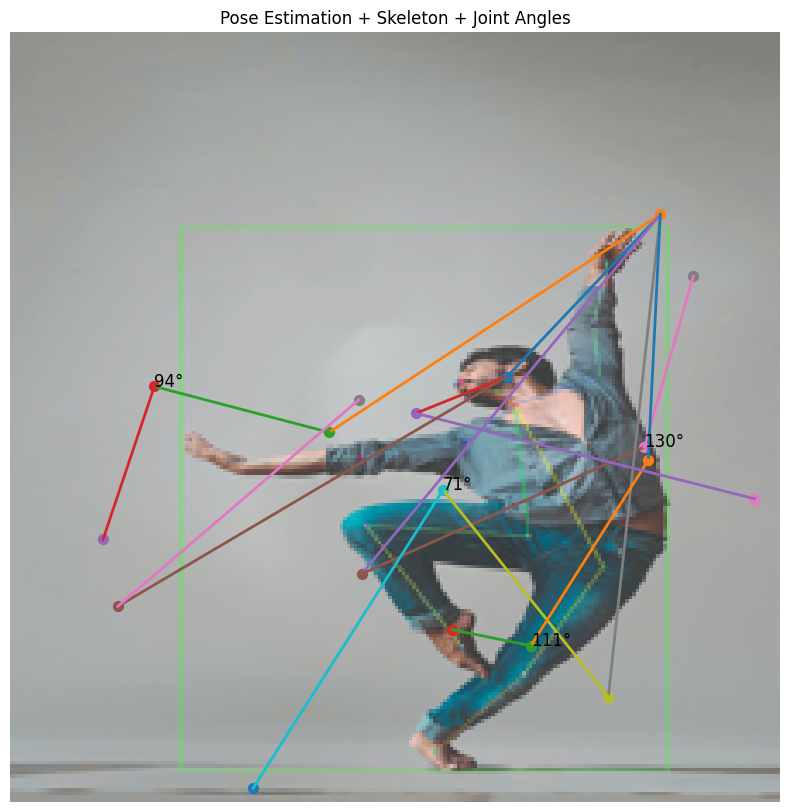

In [24]:
predict_pose("/kaggle/input/datasets/trainingdatapro/pose-estimation/PoseEstimation/collage/26.jpg")